In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/final.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['timestamp'])

df = df.sort_values('timestamp').reset_index(drop=True)

df.head()

,timestamp,solar_irradiance,wind_speed,temperature,humidity,atmospheric_pressure,grid_load_demand
0,2023-01-01 00:00:00,0.0,18.770285,18.094905,53.215610,1004.872349,294.401249
1,2023-01-01 01:00:00,0.0,6.638605,11.669042,63.906997,1009.493484,185.824084
2,2023-01-01 02:00:00,0.0,14.296742,12.945826,26.234179,970.753013,347.363574
3,2023-01-01 03:00:00,0.0,22.357572,38.478603,53.165238,970.833286,193.641771
4,2023-01-01 04:00:00,0.0,11.879943,4.807723,69.228330,977.621817,244.023572


In [ ]:
G = df['solar_irradiance'].values
V = df['wind_speed'].values
Tamb = df['temperature'].values
Pressure = df['atmospheric_pressure'].values * 100
Load = df['grid_load_demand'].values

In [ ]:
# ---- PV Parameters ----
P_pv_rated = 0.4
beta = 0.004
NOCT = 45
G_ref = 1000
f_der = 0.85

# ---- Wind Parameters ----
P_wt_rated = 2
v_ci = 3
v_r = 12
v_co = 25

# ---- Battery Parameters ----
eta_c = 0.9
eta_d = 0.9
SOC_min = 0.2
SOC_max = 0.9

# ---- Cost Parameters ----
cost_pv = 250
cost_wt = 1500
cost_bat = 400

In [ ]:
interest_rate = 0.05
project_life = 20

wind_OM_annual = 100
solar_OM_annual = 0.02 * cost_pv

PW_factor = ((1 + interest_rate)**project_life - 1) / \
            (interest_rate * (1 + interest_rate)**project_life)
print("PW factor =", PW_factor)

PW factor = 12.462210342539992


In [ ]:
def pv_output(Npv):
    Tcell = Tamb + ((NOCT - 20)/800) * G
    Ppv = Npv * P_pv_rated * (G/G_ref) * (1 - beta*(Tcell - 25))*f_der
    Ppv[Ppv < 0] = 0
    return Ppv

In [ ]:
def wind_output(Nwt):

    Pwt = np.zeros_like(V)

    for i in range(len(V)):
        if V[i] < v_ci or V[i] > v_co:
            Pwt[i] = 0
        elif v_ci <= V[i] < v_r:
            Pwt[i] = P_wt_rated*((V[i] - v_ci)/(v_r - v_ci))
        else:
            Pwt[i] = P_wt_rated

    return Nwt * Pwt

In [ ]:
def battery_dispatch_profile(Ppv, Pwt, Cbat):

    SOC = 0.5

    battery_discharge = np.zeros(len(Load))
    battery_charge    = np.zeros(len(Load))
    supplied_power    = np.zeros(len(Load))
    deficit_profile   = np.zeros(len(Load))

    for t in range(len(Load)):

        renewable = Ppv[t] + Pwt[t]
        demand = Load[t]

        if renewable >= demand:

            supplied_power[t] = demand
            surplus = renewable - demand

            available_space = (SOC_max - SOC) * Cbat
            charge = min(surplus, available_space)

            battery_charge[t] = charge

            SOC += (charge * eta_c) / Cbat

        else:

            shortage = demand - renewable

            available_energy = (SOC - SOC_min) * Cbat * eta_d

            discharge = min(shortage, max(0, available_energy))

            battery_discharge[t] = discharge

            SOC -= (discharge / eta_d) / Cbat

            supplied_power[t] = renewable + discharge

            deficit_profile[t] = shortage - discharge

        SOC = max(min(SOC, SOC_max), SOC_min)

    return battery_discharge, battery_charge, supplied_power, deficit_profile

In [ ]:
def npc_objective(x):

    Npv, Nwt, Cbat = x

    Npv = int(round(Npv))
    Nwt = int(round(Nwt))

    if Cbat <= 0:
        return 1e10

    Ppv = pv_output(Npv)
    Pwt = wind_output(Nwt)

    _, _, _, deficit_profile = battery_dispatch_profile(Ppv, Pwt, Cbat)
    deficit = np.sum(deficit_profile)

    capital_cost = (Npv * cost_pv +
                    Nwt * cost_wt +
                    Cbat * cost_bat)

    solar_OM_cost = solar_OM_annual * PW_factor * Npv
    wind_OM_cost  = wind_OM_annual  * PW_factor * Nwt

    penalty_cost = 2000 * deficit

    NPC = capital_cost + solar_OM_cost + wind_OM_cost + penalty_cost

    return NPC

In [ ]:
def PSO(objf, lb, ub, dim, N=40, Max_iter=100, w=0.7, c1=2, c2=2):

    X = np.random.uniform(lb, ub, (N, dim))
    V = np.zeros((N, dim))

    pbest = X.copy()
    pbest_val = np.array([objf(x) for x in X])

    gbest_index = np.argmin(pbest_val)
    gbest = pbest[gbest_index].copy()
    gbest_val = pbest_val[gbest_index]

    curve = []

    for t in range(Max_iter):

        for i in range(N):

            r1 = np.random.rand(dim)
            r2 = np.random.rand(dim)

            V[i] = (w*V[i] +
                    c1*r1*(pbest[i]-X[i]) +
                    c2*r2*(gbest-X[i]))

            X[i] = np.clip(X[i] + V[i], lb, ub)

            X[i][0] = int(round(X[i][0]))
            X[i][1] = int(round(X[i][1]))

            fit = objf(X[i])

            if fit < pbest_val[i]:
                pbest[i] = X[i].copy()
                pbest_val[i] = fit

        best_idx = np.argmin(pbest_val)
        if pbest_val[best_idx] < gbest_val:
            gbest = pbest[best_idx].copy()
            gbest_val = pbest_val[best_idx]

        curve.append(gbest_val)

    return gbest, gbest_val, curve

In [ ]:
def GWO(objective_function, lb, ub, dim, n_agents=40, max_iter=100):

    positions = np.random.uniform(lb, ub, (n_agents, dim))

    alpha_pos = np.zeros(dim)
    alpha_score = float("inf")

    beta_pos = np.zeros(dim)
    beta_score = float("inf")

    delta_pos = np.zeros(dim)
    delta_score = float("inf")

    curve = []

    for iteration in range(max_iter):

        for i in range(n_agents):
            positions[i] = np.clip(positions[i], lb, ub)
            fitness = objective_function(positions[i])

            if fitness < alpha_score:
                alpha_score = fitness
                alpha_pos = positions[i].copy()

            elif fitness < beta_score:
                beta_score = fitness
                beta_pos = positions[i].copy()

            elif fitness < delta_score:
                delta_score = fitness
                delta_pos = positions[i].copy()

        a = 2 - iteration * (2 / max_iter)

        for i in range(n_agents):
            for j in range(dim):

                r1, r2 = np.random.rand(), np.random.rand()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = abs(C1 * alpha_pos[j] - positions[i][j])
                X1 = alpha_pos[j] - A1 * D_alpha

                r1, r2 = np.random.rand(), np.random.rand()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = abs(C2 * beta_pos[j] - positions[i][j])
                X2 = beta_pos[j] - A2 * D_beta

                r1, r2 = np.random.rand(), np.random.rand()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = abs(C3 * delta_pos[j] - positions[i][j])
                X3 = delta_pos[j] - A3 * D_delta

                positions[i][j] = (X1 + X2 + X3) / 3

        curve.append(alpha_score)

    return alpha_pos, alpha_score, curve

In [ ]:
def ABC(objective_function, lb, ub, dim, colony_size=40, max_iter=100, limit=10):

    food_number = colony_size // 2

    foods = np.random.uniform(lb, ub, (food_number, dim))
    fitness = np.array([objective_function(x) for x in foods])

    trial = np.zeros(food_number)

    best_idx = np.argmin(fitness)
    best_sol = foods[best_idx].copy()
    best_cost = fitness[best_idx]

    curve = []

    for iteration in range(max_iter):

        # Employed Bees
        for i in range(food_number):
            k = np.random.randint(0, food_number)
            phi = np.random.uniform(-1, 1, dim)

            new_sol = foods[i] + phi * (foods[i] - foods[k])
            new_sol = np.clip(new_sol, lb, ub)

            new_fit = objective_function(new_sol)

            if new_fit < fitness[i]:
                foods[i] = new_sol
                fitness[i] = new_fit
                trial[i] = 0
            else:
                trial[i] += 1

        # Onlooker Bees
        prob = (1 / (1 + fitness))
        prob = prob / np.sum(prob)

        for i in range(food_number):
            if np.random.rand() < prob[i]:
                k = np.random.randint(0, food_number)
                phi = np.random.uniform(-1, 1, dim)

                new_sol = foods[i] + phi * (foods[i] - foods[k])
                new_sol = np.clip(new_sol, lb, ub)

                new_fit = objective_function(new_sol)

                if new_fit < fitness[i]:
                    foods[i] = new_sol
                    fitness[i] = new_fit
                    trial[i] = 0
                else:
                    trial[i] += 1

        # Scout Bees
        for i in range(food_number):
            if trial[i] > limit:
                foods[i] = np.random.uniform(lb, ub, dim)
                fitness[i] = objective_function(foods[i])
                trial[i] = 0

        # Update best
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_cost:
            best_cost = fitness[best_idx]
            best_sol = foods[best_idx].copy()

        curve.append(best_cost)

    return best_sol, best_cost, curve

In [ ]:
lb = np.array([0, 0, 50])
ub = np.array([2000, 300, 5000])
dim = 3

In [ ]:
best_sol, best_cost, curve = PSO(npc_objective, lb, ub, dim)

print("Optimal Npv =", int(best_sol[0]))
print("Optimal Nwt =", int(best_sol[1]))
print("Optimal Cbat =", round(best_sol[2],2),"kWh")
print("Final NPC =", best_cost)

Optimal Npv = 402
Optimal Nwt = 300
Optimal Cbat = 2536.56 kWh
Final NPC = 1964038.6959729018


In [ ]:
gwo_sol, gwo_cost, gwo_curve = GWO(npc_objective, lb, ub, dim)
abc_sol, abc_cost, abc_curve = ABC(npc_objective, lb, ub, dim)

print("\n--- GWO Result ---")
print("Optimal Npv =", int(gwo_sol[0]))
print("Optimal Nwt =", int(gwo_sol[1]))
print("Optimal Cbat =", round(gwo_sol[2],2), "kWh")
print("Final NPC =", gwo_cost)

print("\n--- ABC Result ---")
print("Optimal Npv =", int(abc_sol[0]))
print("Optimal Nwt =", int(abc_sol[1]))
print("Optimal Cbat =", round(abc_sol[2],2), "kWh")
print("Final NPC =", abc_cost)


--- GWO Result ---
Optimal Npv = 332
Optimal Nwt = 276
Optimal Cbat = 2717.55 kWh
Final NPC = 1951410.1613903968

--- ABC Result ---
Optimal Npv = 343
Optimal Nwt = 279
Optimal Cbat = 2692.17 kWh
Final NPC = 1952933.197746524


In [ ]:
print("\n===== FINAL COMPARISON =====")
print("PSO NPC =", best_cost)
print("GWO NPC =", gwo_cost)
print("ABC NPC =", abc_cost)


===== FINAL COMPARISON =====
PSO NPC = 1964038.6959729018
GWO NPC = 1951410.1613903968
ABC NPC = 1952933.197746524


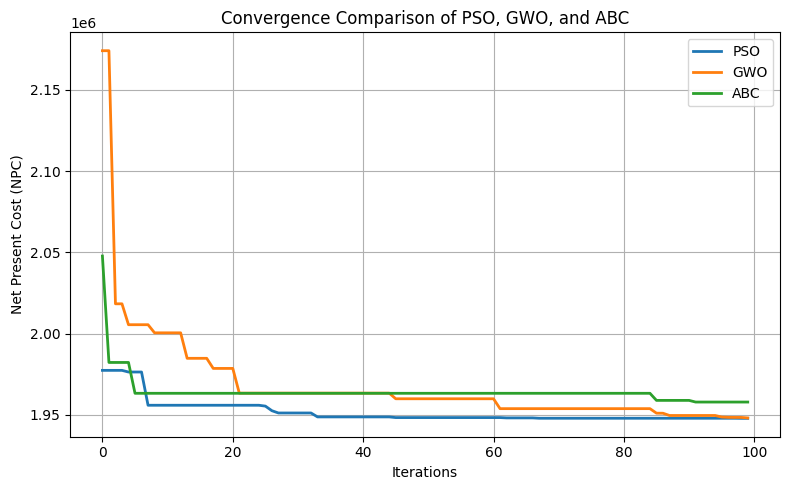

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(curve, label="PSO", linewidth=2)
plt.plot(gwo_curve, label="GWO", linewidth=2)
plt.plot(abc_curve, label="ABC", linewidth=2)

plt.xlabel("Iterations")
plt.ylabel("Net Present Cost (NPC)")
plt.title("Convergence Comparison of PSO, GWO, and ABC")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
Npv_opt = int(abc_sol[0])
Nwt_opt = int(abc_sol[1])
Cbat_opt = abc_sol[2]

Ppv_opt = pv_output(Npv_opt)
Pwt_opt = wind_output(Nwt_opt)

print("Total PV Energy =", np.sum(Ppv_opt))
print("Total Wind Energy =", np.sum(Pwt_opt))
print("Total Load =", np.sum(Load))

Total PV Energy = 120464.44569889239
Total Wind Energy = 1371355.3886306281
Total Load = 961253.05153581


In [ ]:
battery_discharge, battery_charge, supplied_power, deficit_profile = \
    battery_dispatch_profile(Ppv_opt, Pwt_opt, Cbat_opt)

In [ ]:
deficit_events = np.sum(deficit_profile > 0)

total_deficit_energy = np.sum(deficit_profile)

print("Number of deficit timesteps =", deficit_events)
print("Total deficit energy =", total_deficit_energy)

Number of deficit timesteps = 1
Total deficit energy = 4.566031006154873


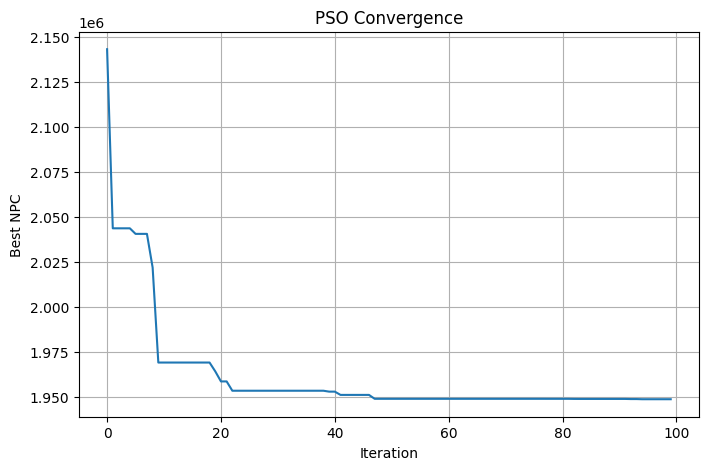

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(curve)
plt.xlabel("Iteration")
plt.ylabel("Best NPC")
plt.title("PSO Convergence")
plt.grid(True)
plt.show()

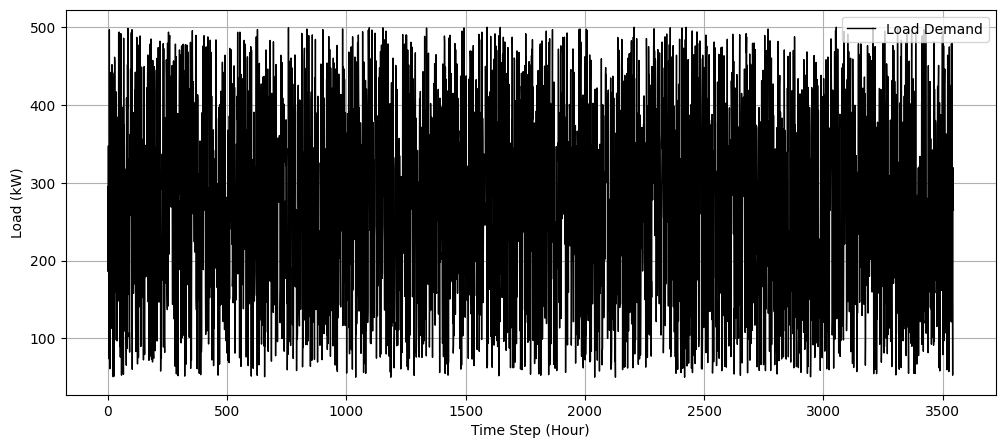

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(Load,
         color='black',
         linewidth=1,
         label='Load Demand')

plt.xlabel('Time Step (Hour)')
plt.ylabel('Load (kW)')
#plt.title('Load Profile of the Dataset')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ======================================
# DETAILED NPC COST BREAKDOWN
# ======================================

# ---- Solar Cost ----
solar_capital = Npv_opt * cost_pv
solar_OM = solar_OM_annual * PW_factor * Npv_opt
solar_total = solar_capital + solar_OM

# ---- Wind Cost ----
wind_capital = Nwt_opt * cost_wt
wind_OM = wind_OM_annual * PW_factor * Nwt_opt
wind_total = wind_capital + wind_OM

# ---- Battery Cost ----
battery_total = Cbat_opt * cost_bat

# ---- Penalty Cost (Unmet Energy) ----
Ppv_opt = pv_output(Npv_opt)
Pwt_opt = wind_output(Nwt_opt)

total_deficit_energy = np.sum(deficit_profile)
penalty_cost = 2000 * total_deficit_energy   # same factor used in optimization

# ---- FINAL NPC ----
NPC_total = solar_total + wind_total + battery_total + penalty_cost

print("===== DETAILED COST BREAKDOWN =====")
print(f"Solar Capital Cost : {solar_capital:.2f}")
print(f"Solar O&M Cost     : {solar_OM:.2f}")
print(f"Solar Total Cost   : {solar_total:.2f}\n")

print(f"Wind Capital Cost  : {wind_capital:.2f}")
print(f"Wind O&M Cost      : {wind_OM:.2f}")
print(f"Wind Total Cost    : {wind_total:.2f}\n")

print(f"Battery Cost       : {battery_total:.2f}\n")

print(f"Penalty Cost       : {penalty_cost:.2f}\n")

print(f"===== TOTAL NPC = {NPC_total:.2f} =====")

===== DETAILED COST BREAKDOWN =====
Solar Capital Cost : 85750.00
Solar O&M Cost     : 21372.69
Solar Total Cost   : 107122.69

Wind Capital Cost  : 418500.00
Wind O&M Cost      : 347695.67
Wind Total Cost    : 766195.67

Battery Cost       : 1076868.62

Penalty Cost       : 9132.06

===== TOTAL NPC = 1959319.04 =====


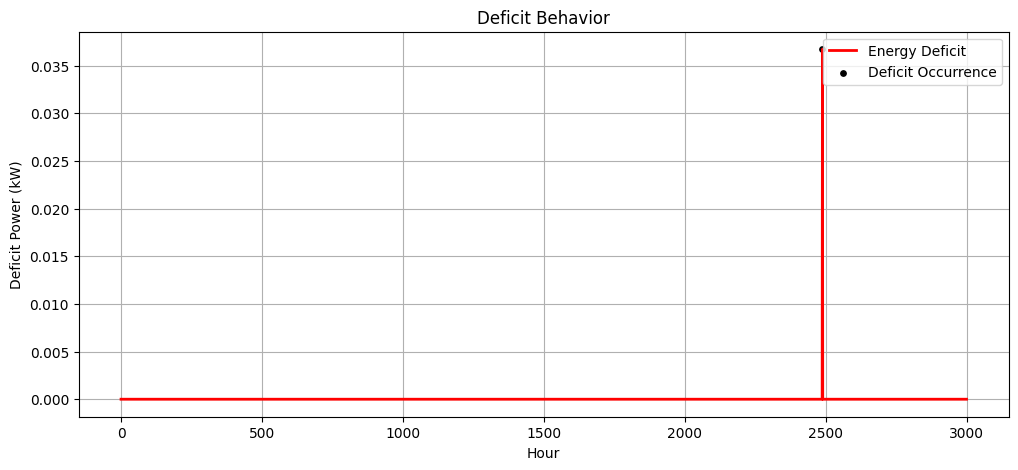

In [ ]:
# ======================================
# ZOOMED DEFICIT TIMELINE (2300–2800)
# ======================================

start = 0
end = 3000
idx = slice(start, end)

# Find deficit points in this range
zoom_deficit_hours = np.where(deficit_profile[idx] > 0)[0] + start

plt.figure(figsize=(12,5))

# Deficit magnitude
plt.plot(range(start, end),
         deficit_profile[idx],
         color='red',
         linewidth=2,
         label='Energy Deficit')

# Highlight deficit events
plt.scatter(zoom_deficit_hours,
            deficit_profile[zoom_deficit_hours],
            color='black',
            s=15,
            label='Deficit Occurrence')

plt.xlabel('Hour')
plt.ylabel('Deficit Power (kW)')
plt.title('Deficit Behavior')
plt.legend()
plt.grid(True)

plt.show()

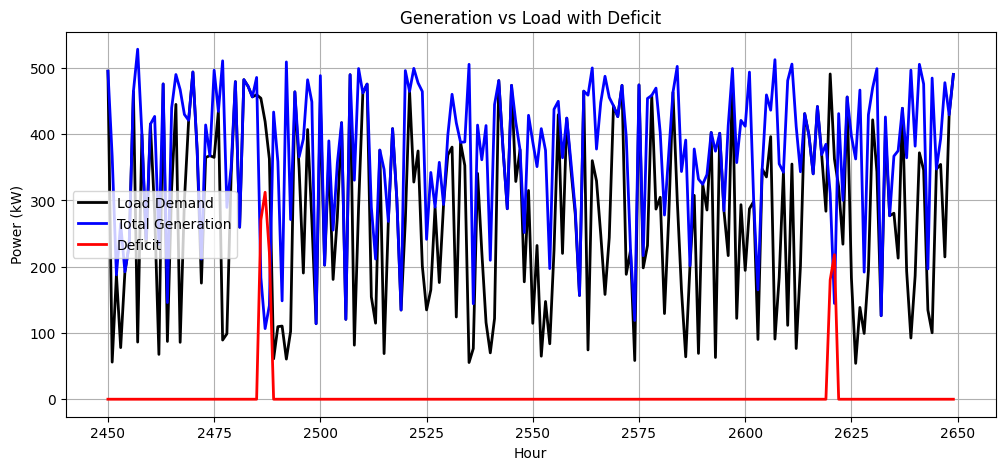

In [ ]:
# ======================================
# ZOOMED GENERATION vs LOAD + DEFICIT
# ======================================

start = 2450
end = 2650
idx = slice(start, end)

# Total generation including battery discharge
total_generation = Ppv_opt + Pwt_opt + battery_discharge

plt.figure(figsize=(12,5))

# Load line
plt.plot(range(start, end),
         Load[idx],
         color='black',
         linewidth=2,
         label='Load Demand')

# Generation line
plt.plot(range(start, end),
         total_generation[idx],
         color='blue',
         linewidth=2,
         label='Total Generation')

# Deficit line
plt.plot(range(start, end),
         deficit_profile[idx],
         color='red',
         linewidth=2,
         label='Deficit')

plt.xlabel('Hour')
plt.ylabel('Power (kW)')
plt.title('Generation vs Load with Deficit')
plt.legend()
plt.grid(True)

plt.show()

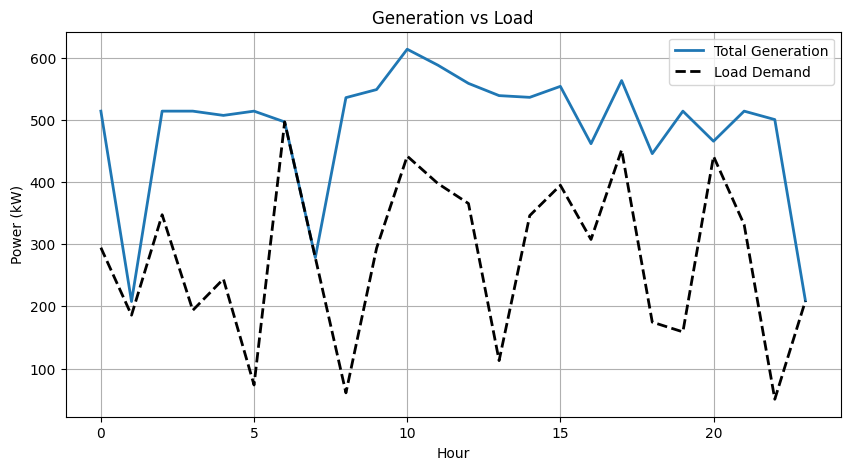

In [ ]:
# ---- First 24 hours only ----
idx = slice(0,24)

# Total generation now includes battery discharge
total_generation = Ppv_opt[idx] + Pwt_opt[idx] + battery_discharge[idx]

plt.figure(figsize=(10,5))

plt.plot(total_generation[idx], label='Total Generation', linewidth=2)
plt.plot(Load[idx], label='Load Demand', linewidth=2, linestyle='--', color='black')

plt.xlabel('Hour')
plt.ylabel('Power (kW)')
plt.title('Generation vs Load')
plt.legend()
plt.grid(True)

plt.show()

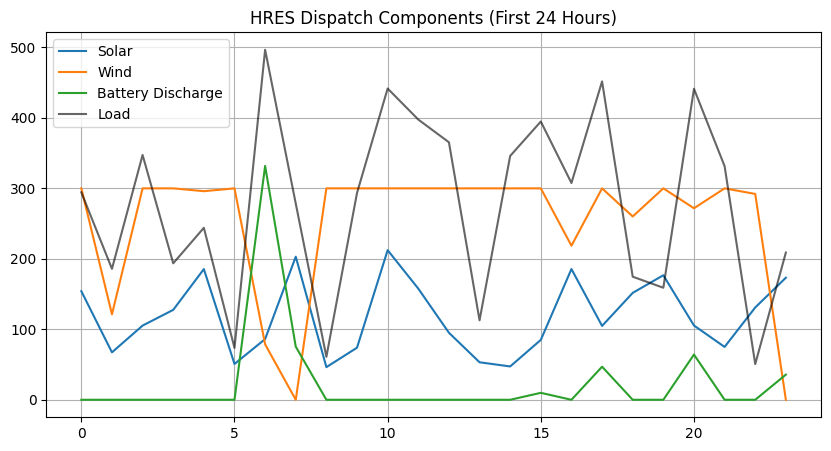

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(Ppv_opt[idx], label='Solar')
plt.plot(Pwt_opt[idx], label='Wind')
plt.plot(battery_discharge[idx], label='Battery Discharge')
plt.plot(Load[idx], label='Load', color='black', alpha=0.6)

plt.legend()
plt.title('HRES Dispatch Components (First 24 Hours)')
plt.grid(True)
plt.show()

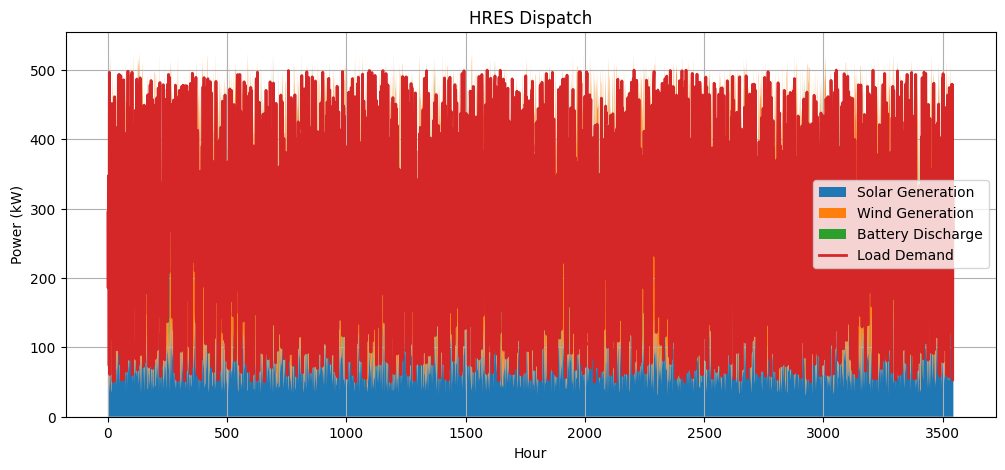

In [ ]:
# ================================
# IEEE-STYLE STACKED DISPATCH PLOT
# ================================

#idx = slice(0,24)

solar = Ppv_opt#[idx]
wind = Pwt_opt#[idx]
battery = battery_discharge#[idx]
load = Load#[idx]

hours = np.arange(len(solar))

plt.figure(figsize=(12,5))

# Stacked generation:
# Solar at bottom
# Wind stacked above solar
# Battery stacked above wind (fills gap)
plt.stackplot(hours,
              solar,
              wind,
              battery,
              labels=['Solar Generation','Wind Generation','Battery Discharge'])

# Load demand as top reference line
plt.plot(hours, load, linewidth=2, label='Load Demand')

plt.xlabel('Hour')
plt.ylabel('Power (kW)')
plt.title('HRES Dispatch')
plt.legend()
plt.grid(True)

plt.show()

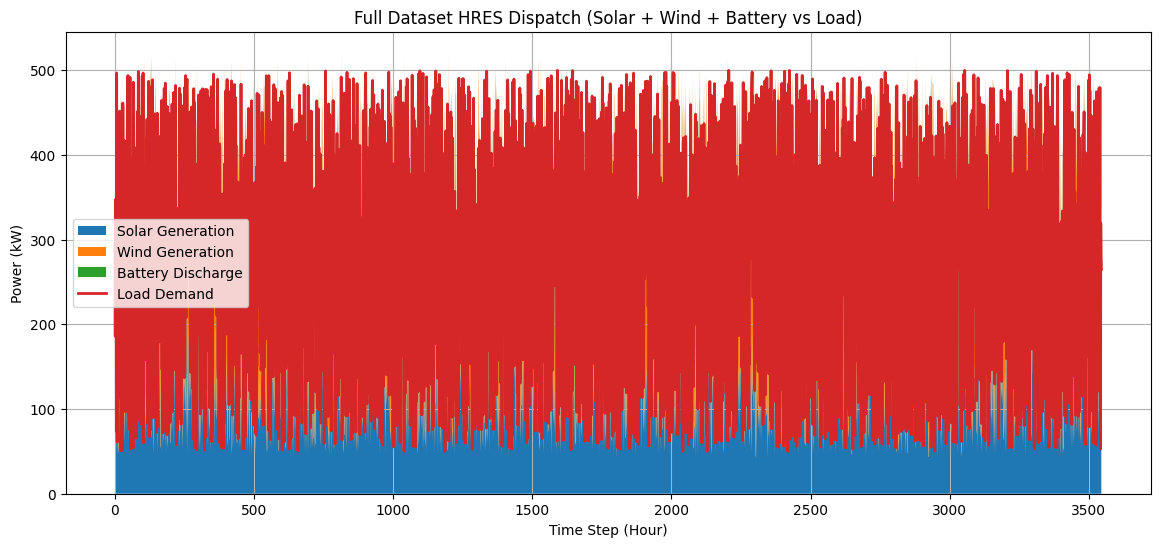

In [ ]:
# ==========================================
# FULL DATASET IEEE-STYLE STACKED DISPATCH
# ==========================================

solar = Ppv_opt
wind = Pwt_opt
battery = battery_discharge
load = Load

hours = np.arange(len(solar))

plt.figure(figsize=(14,6))

# Stacked generation layers
plt.stackplot(hours,
              solar,
              wind,
              battery,
              labels=['Solar Generation','Wind Generation','Battery Discharge'])

# Load demand line
plt.plot(hours, load, linewidth=2, label='Load Demand')

plt.xlabel('Time Step (Hour)')
plt.ylabel('Power (kW)')
plt.title('Full Dataset HRES Dispatch (Solar + Wind + Battery vs Load)')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
Ppv_opt
Pwt_opt
battery_discharge
Load

array([294.401249 , 185.824084 , 347.3635743, ..., 319.4976423,
       278.530184 , 264.9426698])

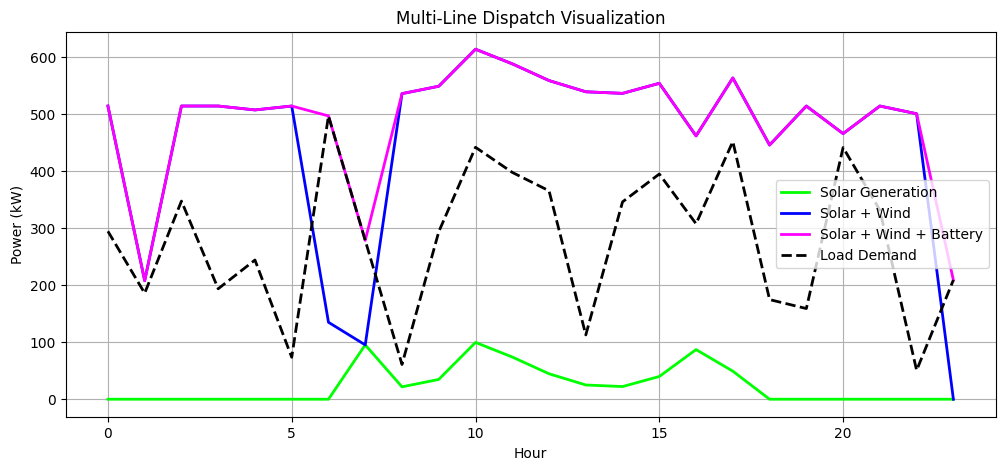

In [ ]:
# ==========================================
# IEEE-STYLE MULTI-LINE DISPATCH (24 HOURS)
# ==========================================

idx = slice(0,24)

# Cumulative generation layers
solar_line = Ppv_opt[idx]
wind_cumulative = Ppv_opt[idx] + Pwt_opt[idx]
battery_cumulative = Ppv_opt[idx] + Pwt_opt[idx] + battery_discharge[idx]

plt.figure(figsize=(12,5))

# Solar base line
plt.plot(solar_line[idx],
         color='lime',
         linewidth=2,
         label='Solar Generation')

# Solar + Wind cumulative
plt.plot(wind_cumulative[idx],
         color='blue',
         linewidth=2,
         label='Solar + Wind')

# Solar + Wind + Battery cumulative
plt.plot(battery_cumulative[idx],
         color='magenta',
         linewidth=2,
         label='Solar + Wind + Battery')

# Load line
plt.plot(Load[idx],
         color='black',
         linestyle='--',
         linewidth=2,
         label='Load Demand')

plt.xlabel('Hour')
plt.ylabel('Power (kW)')
plt.title('Multi-Line Dispatch Visualization')
plt.legend()
plt.grid(True)

plt.show()

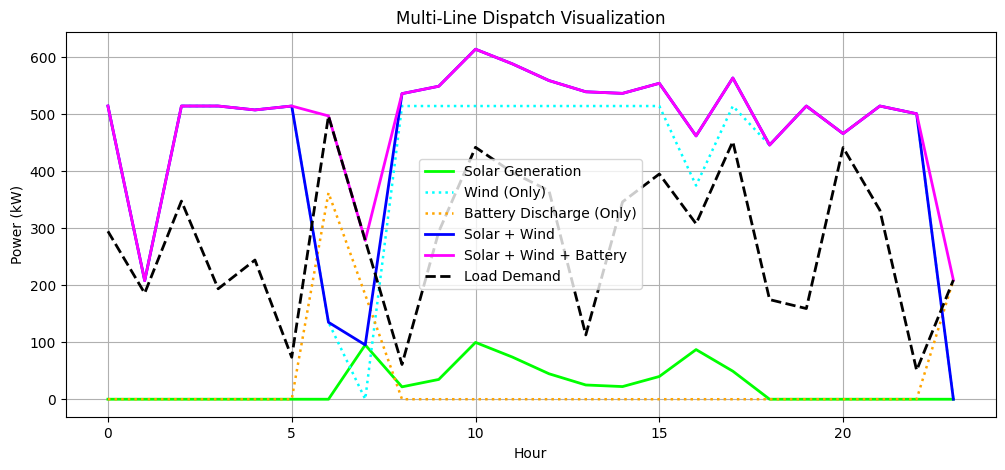

In [ ]:
# ==========================================
# EXTENDED IEEE MULTI-LINE DISPATCH (24H)
# ==========================================

idx = slice(0,24)

# Individual lines
solar_line = Ppv_opt
wind_line = Pwt_opt
battery_line = battery_discharge

# Cumulative dispatch lines
wind_cumulative = Ppv_opt + Pwt_opt
battery_cumulative = Ppv_opt + Pwt_opt + battery_discharge

plt.figure(figsize=(12,5))

# ---- Individual generation lines ----
plt.plot(solar_line[idx],
         color='lime',
         linewidth=2,
         label='Solar Generation')

plt.plot(wind_line[idx],
         color='cyan',
         linewidth=1.8,
         linestyle=':',
         label='Wind (Only)')

plt.plot(battery_line[idx],
         color='orange',
         linewidth=1.8,
         linestyle=':',
         label='Battery Discharge (Only)')

# ---- Cumulative dispatch lines ----
plt.plot(wind_cumulative[idx],
         color='blue',
         linewidth=2,
         label='Solar + Wind')

plt.plot(battery_cumulative[idx],
         color='magenta',
         linewidth=2,
         label='Solar + Wind + Battery')

# ---- Load ----
plt.plot(Load[idx],
         color='black',
         linestyle='--',
         linewidth=2,
         label='Load Demand')

plt.xlabel('Hour')
plt.ylabel('Power (kW)')
plt.title('Multi-Line Dispatch Visualization')
plt.legend()
plt.grid(True)

plt.show()

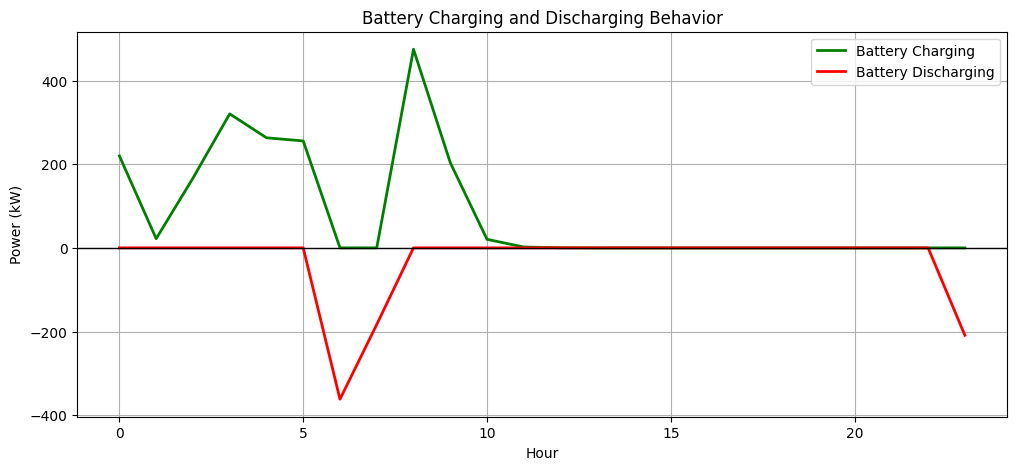

In [ ]:
# ======================================
# BATTERY BEHAVIOR: CHARGE vs DISCHARGE
# ======================================

idx = slice(0,24)

plt.figure(figsize=(12,5))

# Charging (positive values)
plt.plot(battery_charge[idx],
         color='green',
         linewidth=2,
         label='Battery Charging')

# Discharging (negative for visual clarity)
plt.plot(-battery_discharge[idx],
         color='red',
         linewidth=2,
         label='Battery Discharging')

plt.axhline(0, color='black', linewidth=1)

plt.xlabel('Hour')
plt.ylabel('Power (kW)')
plt.title('Battery Charging and Discharging Behavior')
plt.legend()
plt.grid(True)

plt.show()

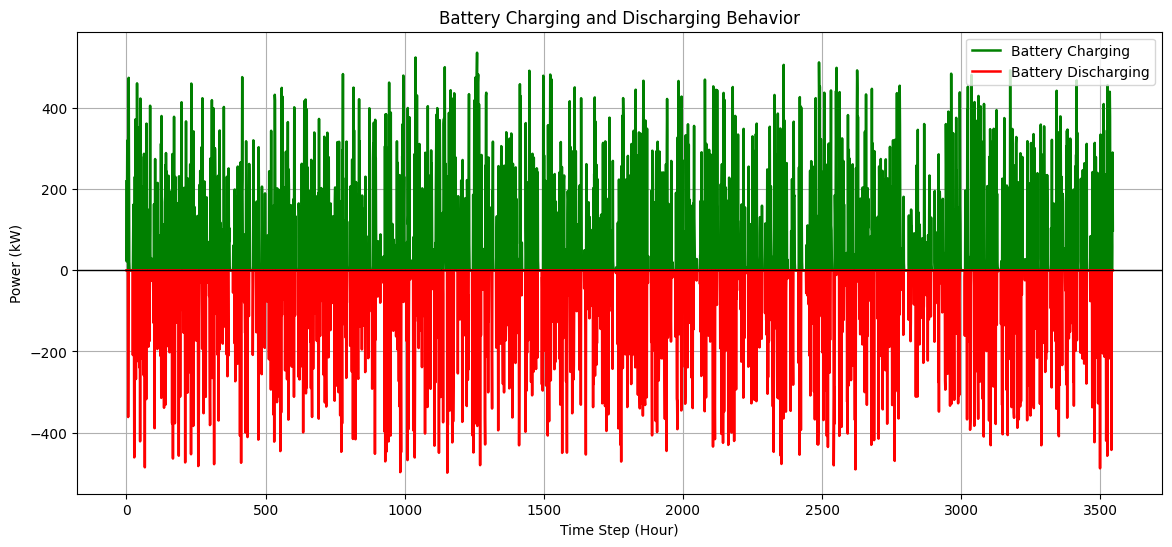

In [ ]:
# ======================================
# FULL DATASET BATTERY BEHAVIOR PLOT
# ======================================

plt.figure(figsize=(14,6))

# Charging → positive (green)
plt.plot(battery_charge,
         color='green',
         linewidth=1.8,
         label='Battery Charging')

# Discharging → shown negative for clear visualization
plt.plot(-battery_discharge,
         color='red',
         linewidth=1.8,
         label='Battery Discharging')

# Zero reference line
plt.axhline(0, color='black', linewidth=1)

plt.xlabel('Time Step (Hour)')
plt.ylabel('Power (kW)')
plt.title('Battery Charging and Discharging Behavior')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
def battery_soc_profile(Ppv, Pwt, Cbat):

    SOC = 0.5
    SOC_profile = np.zeros(len(Load))

    for t in range(len(Load)):

        renewable = Ppv[t] + Pwt[t]
        demand = Load[t]

        # ---- Renewable meets load → charging ----
        if renewable >= demand:

            surplus = renewable - demand
            SOC += (surplus * eta_c) / Cbat

        # ---- Renewable insufficient → discharging ----
        else:

            shortage = demand - renewable
            available_energy = (SOC - SOC_min) * Cbat * eta_d
            discharge = min(shortage, max(0, available_energy))

            SOC -= (discharge / eta_d) / Cbat

        # SOC limits
        SOC = max(min(SOC, SOC_max), SOC_min)

        SOC_profile[t] = SOC

    return SOC_profile

In [ ]:
SOC_profile = battery_soc_profile(Ppv_opt, Pwt_opt, Cbat_opt)

In [ ]:
import numpy as np

print("Mean Solar Generation (kW):", np.mean(Ppv_opt))
print("Mean Wind Generation (kW):", np.mean(Pwt_opt))
print("Maximum Load Demand (kW):", np.max(Load))
print("Average SOC:", np.mean(SOC_profile))
print("Min SOC:", np.min(SOC_profile))
print("Max SOC:", np.max(SOC_profile))

Mean Solar Generation (kW): 148.56526924628955
Mean Wind Generation (kW): 200.4443554312996
Maximum Load Demand (kW): 499.8630242
Average SOC: 0.6925329680658022
Min SOC: 0.2
Max SOC: 0.9


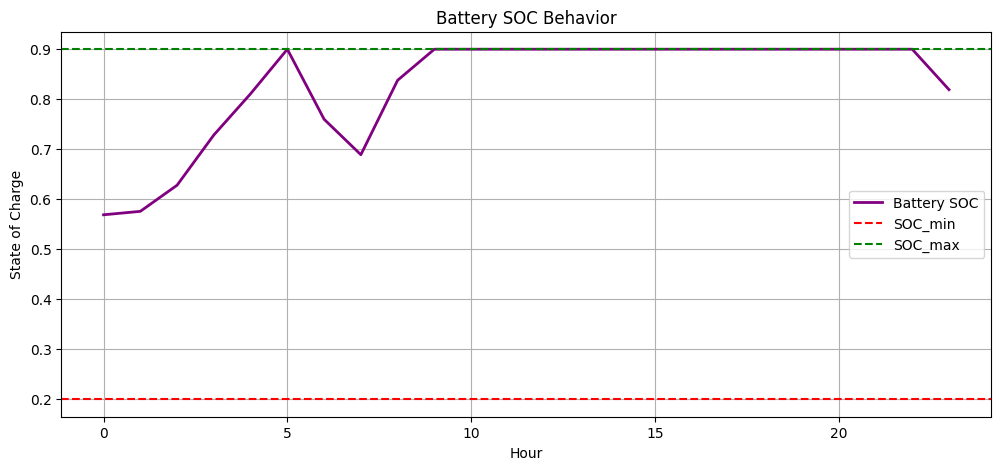

In [ ]:
# ======================================
# SOC BEHAVIOR PLOT (FIRST 24 HOURS)
# ======================================

idx = slice(0,24)

plt.figure(figsize=(12,5))

plt.plot(SOC_profile[idx],
         color='purple',
         linewidth=2,
         label='Battery SOC')

# SOC limits
plt.axhline(SOC_min,
            color='red',
            linestyle='--',
            label='SOC_min')

plt.axhline(SOC_max,
            color='green',
            linestyle='--',
            label='SOC_max')

plt.xlabel('Hour')
plt.ylabel('State of Charge')
plt.title('Battery SOC Behavior')
plt.legend()
plt.grid(True)

plt.show()

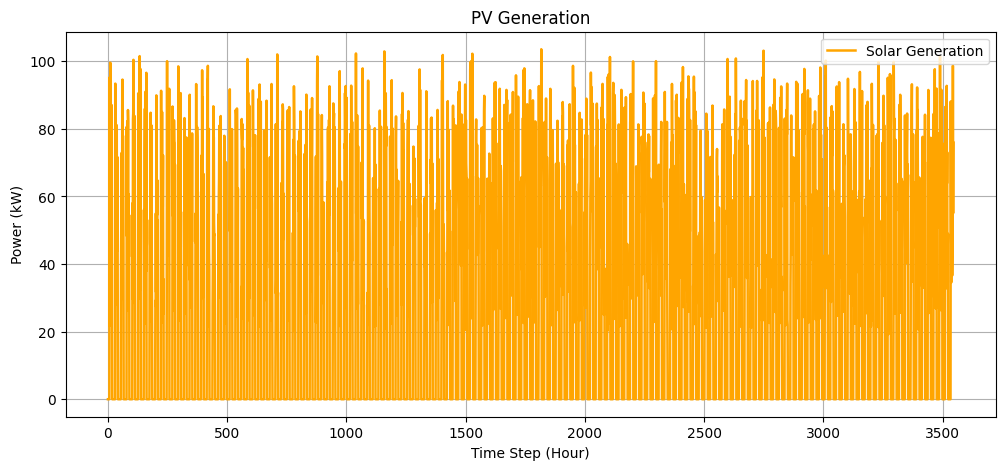

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(Ppv_opt,
         color='orange',
         linewidth=1.8,
         label='Solar Generation')

plt.xlabel('Time Step (Hour)')
plt.ylabel('Power (kW)')
plt.title('PV Generation')
plt.legend()
plt.grid(True)

plt.show()

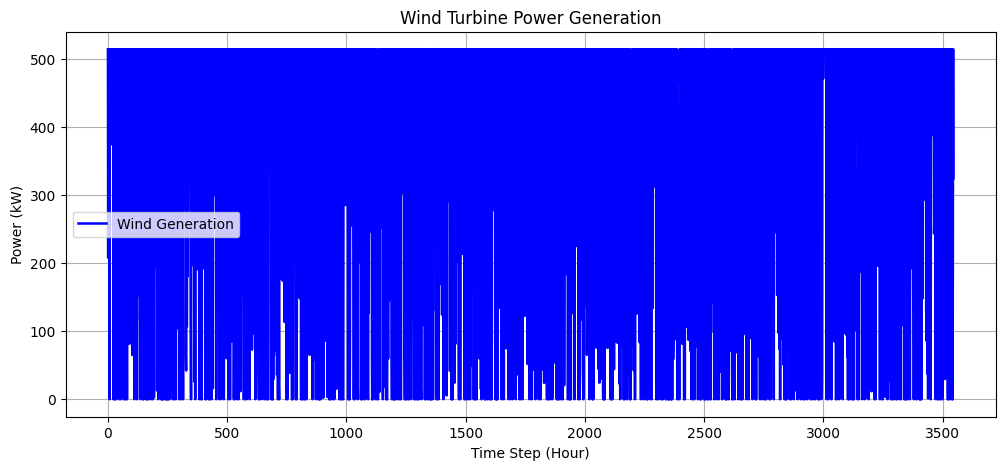

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(Pwt_opt,
         color='blue',
         linewidth=1.8,
         label='Wind Generation')

plt.xlabel('Time Step (Hour)')
plt.ylabel('Power (kW)')
plt.title('Wind Turbine Power Generation')
plt.legend()
plt.grid(True)

plt.show()